In [23]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest,f_classif
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
dataset = pd.read_csv("Tech_Layoff_Hiring_Trends.csv")

In [3]:
dataset.columns

Index(['record_id', 'company_name', 'industry', 'country', 'company_size',
       'month', 'year', 'layoffs_count', 'layoff_percentage',
       'reason_for_layoffs', 'ai_automation_impact', 'ai_replacement_risk',
       'open_roles', 'hiring_trend', 'remote_jobs_percentage',
       'top_hiring_role', 'stock_growth_percent', 'revenue_growth_percent',
       'salary_budget_change', 'ai_adoption_level', 'employee_sentiment',
       'job_security_score', 'market_condition'],
      dtype='object')

In [4]:
dataset

,record_id,company_name,industry,country,company_size,month,year,layoffs_count,layoff_percentage,reason_for_layoffs,...,hiring_trend,remote_jobs_percentage,top_hiring_role,stock_growth_percent,revenue_growth_percent,salary_budget_change,ai_adoption_level,employee_sentiment,job_security_score,market_condition
0,T0,Microsoft,AI,Singapore,Enterprise,Mar,2026,860,1.8,AI Automation,...,Moderate Hiring,46.7,ML Engineer,-25.7,30.3,4.9,4.4,8.7,8.6,Bull Market
1,T1,Palantir,AI,Canada,Big Tech,Feb,2024,955,1.8,Cost Cutting,...,Moderate Hiring,58.9,ML Engineer,-5.6,6.1,1.5,1.0,8.2,7.2,Bull Market
2,T2,Anthropic,Cybersecurity,USA,Mid-size,Apr,2025,18912,9.5,Overhiring Correction,...,Hiring Freeze,85.4,Frontend Developer,7.0,-23.6,-14.9,5.6,4.5,5.9,Recession
3,T3,Spotify,Gaming,USA,Mid-size,Jun,2025,18159,9.1,Cost Cutting,...,Hiring Freeze,44.0,Frontend Developer,31.6,-22.3,-1.6,6.5,5.4,4.7,Recession
4,T4,Uber,Gaming,UK,Startup,Feb,2025,815,3.3,Market Slowdown,...,Moderate Hiring,53.2,Frontend Developer,85.3,26.6,9.8,9.3,6.7,5.8,Bull Market
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,T11995,Anthropic,Gaming,USA,Enterprise,Mar,2024,766,8.4,Market Slowdown,...,Moderate Hiring,15.8,Software Engineer,18.5,-16.8,-0.8,4.0,6.7,5.1,Bull Market
11996,T11996,Intel,Cybersecurity,Canada,Mid-size,Jul,2026,3407,13.9,Restructuring,...,Hiring Freeze,51.8,Cloud Engineer,75.3,9.7,-1.7,2.3,7.7,6.2,Stable
11997,T11997,Netflix,Social Media,USA,Big Tech,Sep,2025,2576,8.7,Market Slowdown,...,Moderate Hiring,88.8,DevOps Engineer,40.9,11.1,10.7,7.0,8.0,5.1,Recession
11998,T11998,Salesforce,Gaming,Germany,Big Tech,Sep,2025,1039,9.1,Overhiring Correction,...,Moderate Hiring,37.6,Cybersecurity Analyst,24.2,44.2,27.4,8.9,7.3,6.2,Bull Market


In [5]:
dataset.isnull().sum()

record_id                 0
company_name              0
industry                  0
country                   0
company_size              0
month                     0
year                      0
layoffs_count             0
layoff_percentage         0
reason_for_layoffs        0
ai_automation_impact      0
ai_replacement_risk       0
open_roles                0
hiring_trend              0
remote_jobs_percentage    0
top_hiring_role           0
stock_growth_percent      0
revenue_growth_percent    0
salary_budget_change      0
ai_adoption_level         0
employee_sentiment        0
job_security_score        0
market_condition          0
dtype: int64

In [8]:
dataset.shape

(12000, 23)

In [9]:
dataset.duplicated().sum()

0

In [10]:
dataset.dropna(how='all',inplace=True)

In [11]:
dataset.shape

(12000, 23)

In [12]:
from Univariate_1 import UnivariateClass
UC=UnivariateClass()

In [13]:
qual=[]
quan=[]

In [14]:
qual,quan=UC.QualQuan(dataset)

In [15]:
qual

['record_id',
 'company_name',
 'industry',
 'country',
 'company_size',
 'month',
 'reason_for_layoffs',
 'hiring_trend',
 'top_hiring_role',
 'market_condition']

In [16]:
quan

['year',
 'layoffs_count',
 'layoff_percentage',
 'ai_automation_impact',
 'ai_replacement_risk',
 'open_roles',
 'remote_jobs_percentage',
 'stock_growth_percent',
 'revenue_growth_percent',
 'salary_budget_change',
 'ai_adoption_level',
 'employee_sentiment',
 'job_security_score']

In [17]:
descriptive=UC.Univariate_Table(dataset,quan)

In [ ]:
lesser=[]
greater=[]

In [18]:
descriptive

,year,layoffs_count,layoff_percentage,ai_automation_impact,ai_replacement_risk,open_roles,remote_jobs_percentage,stock_growth_percent,revenue_growth_percent,salary_budget_change,ai_adoption_level,employee_sentiment,job_security_score
Mean,2025,5009.57,12.7801,6.37698,7.20876,2884.39,50.2052,22.4665,17.4692,5.92039,5.53875,6.49622,5.80503
Median,2025,2733,9.4,5.9,7.6,2282,50.5,22.6,17.5,5.9,5.6,6.5,5.9
Mode,2024,555,8.8,5.9,10,223,68.1,2.1,-15.7,-0.4,7.1,6.6,5.7
Q1:25%,2024,1369.5,5.1,3.5,5.1,1151,29.8,-11.2,-3.5,-2.7,3.3,5.4,4.7
Q2:50%,2025,2733,9.4,5.9,7.6,2282,50.5,22.6,17.5,5.9,5.6,6.5,5.9
Q3:75%,2026,6490,17.3,8.8,10,4432.25,70.7,55.7,38.4,14.6,7.7,7.6,7
99%,2026,19450,39.2,15.2,10,9311.04,89.2,88.5,59.2,30.401,9.9,9.8,9.1
Q4:100%,2026,19999,40,16.8,10,9997,90,90,60,38.2,10,10,10
IQR,2,5120.5,12.2,5.3,4.9,3281.25,40.9,66.9,41.9,17.3,4.4,2.2,2.3
1.5rule,3,7680.75,18.3,7.95,7.35,4921.88,61.35,100.35,62.85,25.95,6.6,3.3,3.45


In [19]:
lesser,greater=UC.check_OutlierColumns(descriptive,quan)

In [20]:
lesser

['employee_sentiment', 'job_security_score']

In [21]:
greater

['layoffs_count', 'layoff_percentage', 'ai_automation_impact', 'open_roles']

In [22]:
UC.replace_Outlier(dataset,descriptive,lesser,greater)

D:\AI_Course_Tamil\ML&DS_CapstoneProject\Univariate_1.py:74: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset[columnName][dataset[columnName]<descriptive[columnName]["Lesser"]]=descriptive[columnName]["Lesser"]
D:\AI_Course_Tamil\ML&DS_CapstoneProject\Univariate_1.py:76: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset[columnName][dataset[columnName]>descriptive[columnName]["Greater"]]=descriptive[columnName]["Greater"]
D:\AI_Course_Tamil\ML&DS_CapstoneProject\Univariate_1.py:76: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: htt

In [24]:
dataset.describe()

,year,layoffs_count,layoff_percentage,ai_automation_impact,ai_replacement_risk,open_roles,remote_jobs_percentage,stock_growth_percent,revenue_growth_percent,salary_budget_change,ai_adoption_level,employee_sentiment,job_security_score
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,2024.998750,4716.084208,12.673025,6.376979,7.208758,2881.511094,50.205150,22.466550,17.469175,5.920392,5.538750,6.497217,5.805654
std,0.817703,4471.400681,9.953661,3.544000,2.677148,2140.635208,23.299575,38.814405,24.359448,11.777264,2.583047,1.579421,1.647921
min,2024.000000,0.000000,0.000000,0.600000,1.000000,52.000000,10.000000,-45.000000,-25.000000,-28.000000,1.000000,2.100000,1.250000
25%,2024.000000,1369.500000,5.100000,3.500000,5.100000,1151.000000,29.800000,-11.200000,-3.500000,-2.700000,3.300000,5.400000,4.700000
50%,2025.000000,2733.000000,9.400000,5.900000,7.600000,2282.000000,50.500000,22.600000,17.500000,5.900000,5.600000,6.500000,5.900000
75%,2026.000000,6490.000000,17.300000,8.800000,10.000000,4432.250000,70.700000,55.700000,38.400000,14.600000,7.700000,7.600000,7.000000
max,2026.000000,14170.750000,35.600000,16.750000,10.000000,9354.125000,90.000000,90.000000,60.000000,38.200000,10.000000,10.000000,10.000000


In [25]:
dataset.columns

Index(['record_id', 'company_name', 'industry', 'country', 'company_size',
       'month', 'year', 'layoffs_count', 'layoff_percentage',
       'reason_for_layoffs', 'ai_automation_impact', 'ai_replacement_risk',
       'open_roles', 'hiring_trend', 'remote_jobs_percentage',
       'top_hiring_role', 'stock_growth_percent', 'revenue_growth_percent',
       'salary_budget_change', 'ai_adoption_level', 'employee_sentiment',
       'job_security_score', 'market_condition'],
      dtype='object')

In [26]:
def selectkbest(indep_X,dep_Y,n):
        test = SelectKBest(score_func=f_classif, k=n)
        
        #selected_features = X.columns[mask].tolist()
        #print(test.get_params
        
        fit1= test.fit(indep_X,dep_Y)
        selectk_features = fit1.transform(indep_X)
        mask=test.get_support()
        selected_features = indep_X.columns[mask].tolist()
        print(selected_features)
        return selectk_features

In [27]:
dataset.drop("record_id",axis=1,inplace=True)

In [28]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
dataset['market_condition'] = le.fit_transform(dataset['market_condition'])

In [29]:
dataset = pd.get_dummies(
    dataset,
    columns=['hiring_trend'],
    drop_first=True,dtype=int
)


In [30]:
dataset

,company_name,industry,country,company_size,month,year,layoffs_count,layoff_percentage,reason_for_layoffs,ai_automation_impact,...,stock_growth_percent,revenue_growth_percent,salary_budget_change,ai_adoption_level,employee_sentiment,job_security_score,market_condition,hiring_trend_Downsizing,hiring_trend_Hiring Freeze,hiring_trend_Moderate Hiring
0,Microsoft,AI,Singapore,Enterprise,Mar,2026,860.00,1.8,AI Automation,6.4,...,-25.7,30.3,4.9,4.4,8.7,8.6,0,0,0,1
1,Palantir,AI,Canada,Big Tech,Feb,2024,955.00,1.8,Cost Cutting,0.9,...,-5.6,6.1,1.5,1.0,8.2,7.2,0,0,0,1
2,Anthropic,Cybersecurity,USA,Mid-size,Apr,2025,14170.75,9.5,Overhiring Correction,7.1,...,7.0,-23.6,-14.9,5.6,4.5,5.9,1,0,1,0
3,Spotify,Gaming,USA,Mid-size,Jun,2025,14170.75,9.1,Cost Cutting,10.4,...,31.6,-22.3,-1.6,6.5,5.4,4.7,1,0,1,0
4,Uber,Gaming,UK,Startup,Feb,2025,815.00,3.3,Market Slowdown,11.4,...,85.3,26.6,9.8,9.3,6.7,5.8,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,Anthropic,Gaming,USA,Enterprise,Mar,2024,766.00,8.4,Market Slowdown,5.6,...,18.5,-16.8,-0.8,4.0,6.7,5.1,0,0,0,1
11996,Intel,Cybersecurity,Canada,Mid-size,Jul,2026,3407.00,13.9,Restructuring,3.4,...,75.3,9.7,-1.7,2.3,7.7,6.2,2,0,1,0
11997,Netflix,Social Media,USA,Big Tech,Sep,2025,2576.00,8.7,Market Slowdown,8.3,...,40.9,11.1,10.7,7.0,8.0,5.1,1,0,0,1
11998,Salesforce,Gaming,Germany,Big Tech,Sep,2025,1039.00,9.1,Overhiring Correction,9.1,...,24.2,44.2,27.4,8.9,7.3,6.2,0,0,0,1


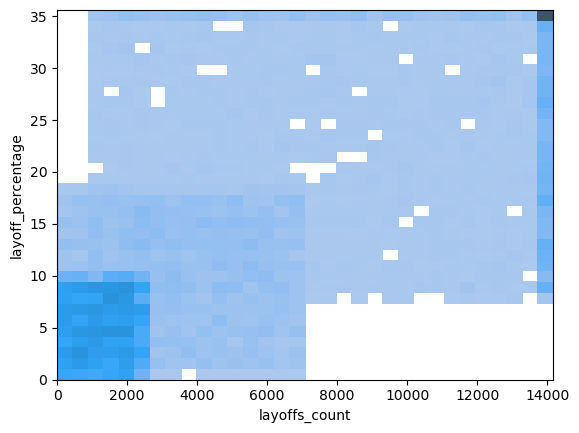

In [31]:
sns.histplot(x=dataset['layoffs_count'],y=dataset['layoff_percentage'],kde=True)

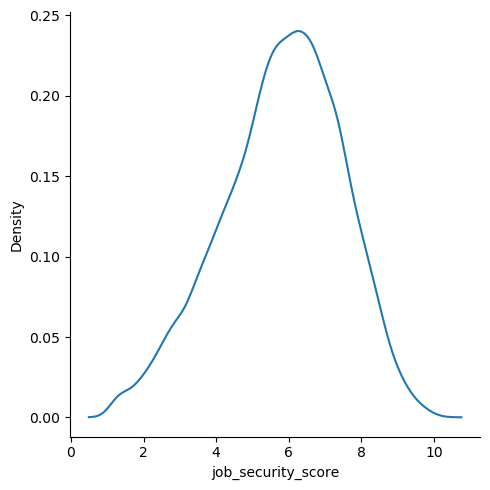

In [32]:
sns.displot(dataset['job_security_score'],kind='kde')

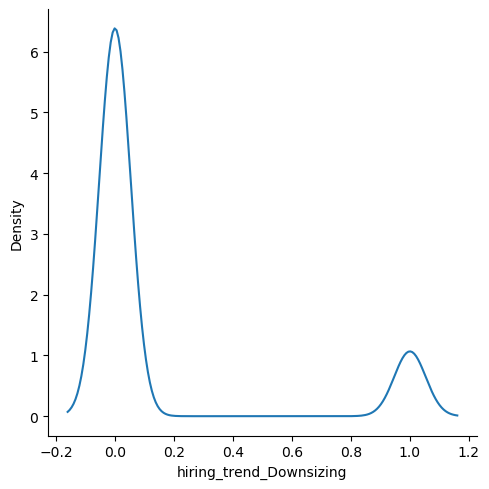

In [33]:
sns.displot(dataset['hiring_trend_Downsizing'],kind='kde')

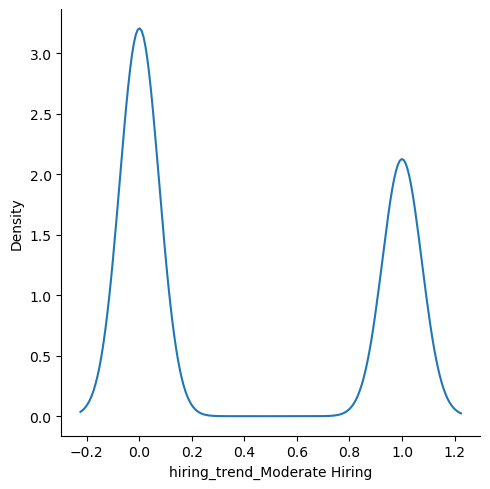

In [34]:
sns.displot(dataset['hiring_trend_Moderate Hiring'],kind='kde')

In [35]:
indep_X=dataset[['layoffs_count',
                'layoff_percentage',
                'job_security_score',
                'hiring_trend_Downsizing',
                'hiring_trend_Moderate Hiring']]

In [36]:
print(indep_X.columns)

Index(['layoffs_count', 'layoff_percentage', 'job_security_score',
       'hiring_trend_Downsizing', 'hiring_trend_Moderate Hiring'],
      dtype='object')


In [37]:
indep_X

,layoffs_count,layoff_percentage,job_security_score,hiring_trend_Downsizing,hiring_trend_Moderate Hiring
0,860.00,1.8,8.6,0,1
1,955.00,1.8,7.2,0,1
2,14170.75,9.5,5.9,0,0
3,14170.75,9.1,4.7,0,0
4,815.00,3.3,5.8,0,1
...,...,...,...,...,...
11995,766.00,8.4,5.1,0,1
11996,3407.00,13.9,6.2,0,0
11997,2576.00,8.7,5.1,0,1
11998,1039.00,9.1,6.2,0,1


In [38]:
dep_Y=dataset['market_condition']

In [39]:
dep_Y

0        0
1        0
2        1
3        1
4        0
        ..
11995    0
11996    2
11997    1
11998    0
11999    0
Name: market_condition, Length: 12000, dtype: int32

In [40]:
dataset['market_condition'].value_counts()

2    4078
0    4019
1    3903
Name: market_condition, dtype: int64

In [41]:
dep_Y

0        0
1        0
2        1
3        1
4        0
        ..
11995    0
11996    2
11997    1
11998    0
11999    0
Name: market_condition, Length: 12000, dtype: int32

In [42]:
kbest=selectkbest(indep_X,dep_Y,5)

['layoffs_count', 'layoff_percentage', 'job_security_score', 'hiring_trend_Downsizing', 'hiring_trend_Moderate Hiring']


In [43]:
#split into training set and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(indep_X, dep_Y, test_size = 1/3, random_state = 0)

In [44]:
from sklearn.ensemble import RandomForestClassifier

In [45]:
from sklearn.model_selection import GridSearchCV

param_grid = {'criterion':['gini','entropy'],
              'max_features': ['auto','sqrt'],
              'n_estimators':[10,100]} 
grid = GridSearchCV(RandomForestClassifier(), param_grid, refit = True, verbose = 3,n_jobs=-1,scoring='f1_macro') 

grid.fit(X_train,y_train) 

Fitting 3 folds for each of 8 candidates, totalling 24 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of  24 | elapsed:    4.2s remaining:   47.3s
[Parallel(n_jobs=-1)]: Done  11 out of  24 | elapsed:    4.6s remaining:    5.4s
[Parallel(n_jobs=-1)]: Done  20 out of  24 | elapsed:    5.8s remaining:    1.1s
[Parallel(n_jobs=-1)]: Done  24 out of  24 | elapsed:    6.1s finished


GridSearchCV(cv='warn', error_score='raise-deprecating',
             estimator=RandomForestClassifier(bootstrap=True, class_weight=None,
                                              criterion='gini', max_depth=None,
                                              max_features='auto',
                                              max_leaf_nodes=None,
                                              min_impurity_decrease=0.0,
                                              min_impurity_split=None,
                                              min_samples_leaf=1,
                                              min_samples_split=2,
                                              min_weight_fraction_leaf=0.0,
                                              n_estimators='warn', n_jobs=None,
                                              oob_score=False,
                                              random_state=None, verbose=0,
                                              warm_start=False),
           

In [46]:
print(grid.best_params_)

{'criterion': 'entropy', 'max_features': 'sqrt', 'n_estimators': 100}


In [47]:
# print best parameter after tuning 
#print(grid.best_params_) 
re=grid.cv_results_
#print(re)
grid_predictions = grid.predict(X_test) 
   

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, grid_predictions)



# print classification report 
from sklearn.metrics import classification_report
clf_report = classification_report(y_test, grid_predictions)

In [48]:
print(grid.predict(X_test))

[1 0 1 ... 0 1 0]


In [49]:
pred = grid.predict(X_test)
print(np.unique(pred))

[0 1 2]


In [50]:
table=pd.DataFrame.from_dict(re)

In [51]:
table

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_features,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.135911,0.006154,0.020036,0.001277,gini,auto,10,"{'criterion': 'gini', 'max_features': 'auto', ...",0.881184,0.880253,0.875842,0.879093,0.002330,5
1,1.147731,0.015662,0.085460,0.002204,gini,auto,100,"{'criterion': 'gini', 'max_features': 'auto', ...",0.886931,0.889419,0.885433,0.887261,0.001644,2
2,0.131670,0.007048,0.023824,0.003177,gini,sqrt,10,"{'criterion': 'gini', 'max_features': 'sqrt', ...",0.864880,0.880933,0.874749,0.873518,0.006611,8
3,1.150326,0.004262,0.076643,0.002373,gini,sqrt,100,"{'criterion': 'gini', 'max_features': 'sqrt', ...",0.885070,0.889081,0.885486,0.886545,0.001801,4
4,0.167617,0.003671,0.015831,0.001642,entropy,auto,10,"{'criterion': 'entropy', 'max_features': 'auto...",0.875072,0.879750,0.873924,0.876248,0.002519,7
5,1.442188,0.041624,0.066456,0.000838,entropy,auto,100,"{'criterion': 'entropy', 'max_features': 'auto...",0.887440,0.889935,0.883202,0.886859,0.002779,3
6,0.155997,0.002174,0.014441,0.000884,entropy,sqrt,10,"{'criterion': 'entropy', 'max_features': 'sqrt...",0.877868,0.877175,0.876812,0.877285,0.000438,6
7,1.387609,0.028662,0.069731,0.001761,entropy,sqrt,100,"{'criterion': 'entropy', 'max_features': 'sqrt...",0.884378,0.893166,0.884314,0.887285,0.004157,1


In [52]:
from sklearn.metrics import f1_score
f1_macro=f1_score(y_test,grid_predictions,average='weighted')
print("The f1_macro value for best parameter {}:".format(grid.best_params_),f1_macro)

The f1_macro value for best parameter {'criterion': 'entropy', 'max_features': 'sqrt', 'n_estimators': 100}: 0.899725214523489


In [53]:
print("The confusion Matrix:\n",cm)

The confusion Matrix:
 [[1284    0   34]
 [   7 1238  110]
 [ 228   21 1078]]


In [54]:
print("The report:\n",clf_report)

The report:
               precision    recall  f1-score   support

           0       0.85      0.97      0.91      1318
           1       0.98      0.91      0.95      1355
           2       0.88      0.81      0.85      1327

    accuracy                           0.90      4000
   macro avg       0.90      0.90      0.90      4000
weighted avg       0.90      0.90      0.90      4000



In [55]:
import pickle
filename='rf_final_model.sav'
pickle.dump(grid,open(filename,'wb'))
loaded_model=pickle.load(open(filename,'rb'))

layoffs_count=float(input("Layoffs Count: "))
layoff_percentage=float(input("layoff_percentage:"))
job_security_score=float(input("job_security_score:"))
hiring_trend_Downsizing=float(input("hiring_trend_Downsizing:"))
hiring_trend_Moderate_Hiring=float(input("hiring_trend_Moderate_Hiring:"))

prediction=loaded_model.predict([[layoffs_count,
                layoff_percentage,
                job_security_score,
                hiring_trend_Downsizing,
                hiring_trend_Moderate_Hiring]])
print("\n Prediction : 0 - Bull Market")
print("\n              1 - Recession")
print("\n              2 - Stable")

print("\n Prediction : ",prediction[0])

Layoffs Count: 860
layoff_percentage:1.8
job_security_score:8.6
hiring_trend_Downsizing:0
hiring_trend_Moderate_Hiring:1

 Prediction : 0 - Bull Market

              1 - Recession

              2 - Stable

 Prediction :  0
